In [1]:
import os
import gc
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tắt các cảnh báo không cần thiết
warnings.filterwarnings("ignore")

# Cấu hình TensorFlow để tối ưu cho GPU RTX 3050 (4GB VRAM)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Input, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print(f"✓ TensorFlow Version: {tf.__version__}")

✓ TensorFlow Version: 2.10.1


In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    # Bật Mixed Precision để tối ưu cho kiến trúc Ampere (RTX 30 series)
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print(f"✓ Đã tìm thấy GPU: {gpus[0].name}")
else:
    print("⚠ Không tìm thấy GPU, sử dụng CPU.")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
✓ Đã tìm thấy GPU: /physical_device:GPU:0


In [3]:
WINDOW_SIZE = 24       
HORIZON = 6            
# 🚀 GIẢM BATCH_SIZE xuống 32 để mô hình học các biến động nhỏ chi tiết hơn
BATCH_SIZE = 32        
EPOCHS = 100

DATA_PATH = r"C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\data\finally\final_dataset_target_6h.csv"
MODEL_DIR = r"C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\models\lstm"
os.makedirs(MODEL_DIR, exist_ok=True)

# 🚀 THAY ĐỔI QUAN TRỌNG:
# - XÓA 'wind_dir'
# - THÊM 'wind_sin', 'wind_cos' để LSTM không bị lỗi vòng lặp 360 -> 0
# - THÊM 'is_weekend' để mô hình phân biệt ngày nghỉ của xưởng
SELECTED_FEATURES = [
    'aqi_current', 'pm25', 'wind_speed', 'o3', 'hour_sin', 'hour_cos', 
    'temperature', 'pressure', 'humidity', 'wind_sin', 'wind_cos', 'pm10',
    'pm25_trend', 'wind_trend', 'is_weekend'
]

TARGET_COL = 'aqi_diff_6h'

In [4]:
def build_sequences(df, feature_cols, target_col, window_size):
    X, y = [], []
    # Xử lý theo từng làng nghề để tránh lẫn lộn dữ liệu
    for village, group in df.groupby('village'):
        group = group.sort_values('timestamp').reset_index(drop=True)
        feat_data = group[feature_cols].values
        target_data = group[target_col].values
        
        for i in range(len(group) - window_size):
            X.append(feat_data[i : i + window_size])
            # Sửa lỗi: Lấy đúng dòng cuối của cửa sổ (vì dòng đó đã chứa sẵn t+6)
            y.append(target_data[i + window_size - 1]) 
            
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [5]:
print(f"📥 Đang tải dữ liệu: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Tạo bù tính năng nếu thiếu
if 'wind_sin' not in df.columns:
    wind_rad = np.deg2rad(df["wind_dir"].fillna(0))
    df["wind_sin"] = np.sin(wind_rad)
    df["wind_cos"] = np.cos(wind_rad)

if 'is_weekend' not in df.columns:
    df["is_weekend"] = (df["timestamp"].dt.dayofweek >= 5).astype(int)

# 🚀 THAY ĐỔI: BỎ aqi_diff_6h, quay về dự báo trực tiếp AQI để tránh mô hình học "lười"
TARGET_COL = 'target_aqi_6h'

# Tính đà biến động (Momentum)
df['pm25_trend'] = df.groupby('village')['pm25'].diff().fillna(0)
df['wind_trend'] = df.groupby('village')['wind_speed'].diff().fillna(0)

# Chia tập
train_df = df[df['timestamp'] < '2025-08-01'].copy()
val_df   = df[(df['timestamp'] >= '2025-08-01') & (df['timestamp'] < '2026-01-01')].copy()
test_df  = df[df['timestamp'] >= '2026-01-01'].copy()

# Scaling
scaler_x = StandardScaler()
scaler_y = StandardScaler()

train_df.loc[:, SELECTED_FEATURES] = scaler_x.fit_transform(train_df[SELECTED_FEATURES])
val_df.loc[:, SELECTED_FEATURES]   = scaler_x.transform(val_df[SELECTED_FEATURES])
test_df.loc[:, SELECTED_FEATURES]  = scaler_x.transform(test_df[SELECTED_FEATURES])

train_df.loc[:, [TARGET_COL]] = scaler_y.fit_transform(train_df[[TARGET_COL]])
val_df.loc[:, [TARGET_COL]]   = scaler_y.transform(val_df[[TARGET_COL]])
test_df.loc[:, [TARGET_COL]]  = scaler_y.transform(test_df[[TARGET_COL]])

X_train, y_train = build_sequences(train_df, SELECTED_FEATURES, TARGET_COL, WINDOW_SIZE)
X_val, y_val     = build_sequences(val_df, SELECTED_FEATURES, TARGET_COL, WINDOW_SIZE)
X_test, y_test   = build_sequences(test_df, SELECTED_FEATURES, TARGET_COL, WINDOW_SIZE)

print(f"✅ Đã chuẩn bị xong. X_train shape: {X_train.shape}")

📥 Đang tải dữ liệu: C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\data\finally\final_dataset_target_6h.csv
✅ Đã chuẩn bị xong. X_train shape: (249246, 24, 15)


In [6]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

def build_cnn_lstm_model(input_shape):
    inputs = Input(shape=input_shape)

    # 🚀 1. LỚP CONV1D: Trích xuất các điểm uốn (sườn dốc) của Thời tiết và PM2.5
    # Điều này bắt buộc mô hình phải học sự biến động, thay vì copy giá trị cũ
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)

    # 2. LỚP LSTM: Phân tích chuỗi tín hiệu đã được Conv1D nén
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = LSTM(32, return_sequences=False)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Dense(32, activation="relu")(x)
    outputs = Dense(1, dtype="float32")(x)

    model = Model(inputs, outputs, name="CNN_LSTM_AQI")
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    return model

model = build_cnn_lstm_model((WINDOW_SIZE, len(SELECTED_FEATURES)))
model.summary()

Model: "CNN_LSTM_AQI"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 24, 15)]          0         
                                                                 
 conv1d (Conv1D)             (None, 24, 64)            2944      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 12, 64)           0         
 )                                                               
                                                                 
 lstm (LSTM)                 (None, 12, 64)            33024     
                                                                 
 batch_normalization (BatchN  (None, 12, 64)           256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 12, 64)           

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint(os.path.join(MODEL_DIR, "best_lstm_model.h5"), save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Dự báo và chuyển ngược về giá trị AQI thật
y_pred_scaled = model.predict(X_test)
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Tính toán các chỉ số
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("="*40)
print("🎯 KẾT QUẢ DỰ BÁO CNN-LSTM (Trực tiếp)")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")
print("="*40)

1509/1509 [==============================] - 7s 4ms/step
🎯 KẾT QUẢ DỰ BÁO LSTM (Đã quy đổi về AQI thực tế)
MAE  : 20.99
RMSE : 28.22
R2   : 0.5958


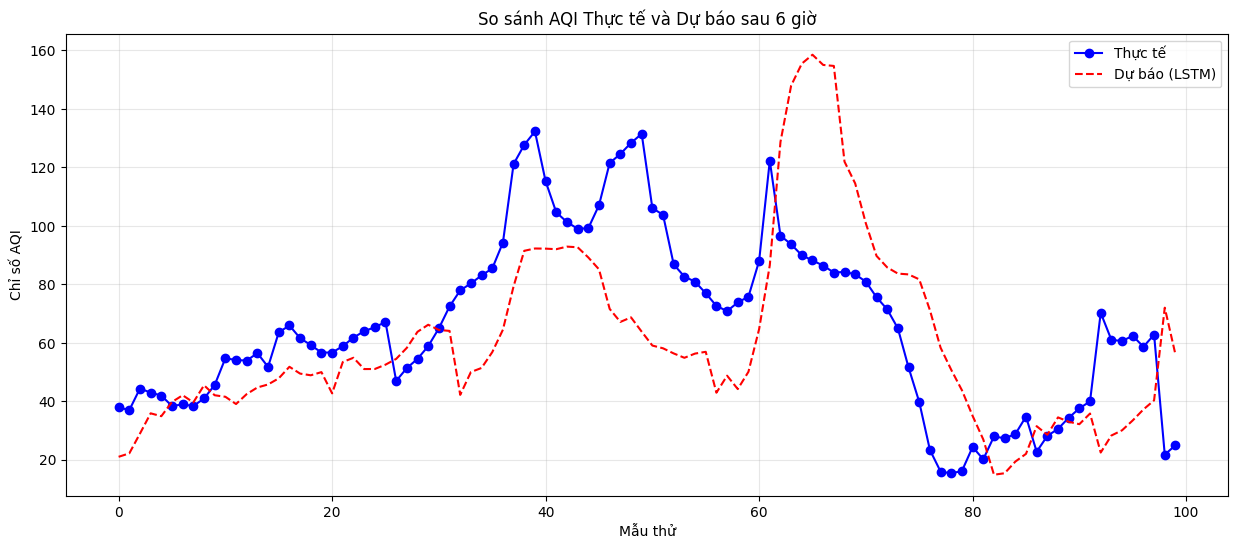

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:100], label="Thực tế", marker="o", color="blue")
plt.plot(y_pred_real[:100], label="Dự báo (LSTM)", linestyle="dashed", color="red")
plt.title(f"So sánh AQI Thực tế và Dự báo sau {HORIZON} giờ")
plt.xlabel("Mẫu thử")
plt.ylabel("Chỉ số AQI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
metadata = {
    "model_type": "LSTM_Attention",
    "metrics": {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)},
    "config": {"window": WINDOW_SIZE, "horizon": HORIZON, "features": SELECTED_FEATURES}
}

with open(os.path.join(MODEL_DIR, "metadata_lstm.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("🚀 Huấn luyện và lưu mô hình hoàn tất!")

🚀 Huấn luyện và lưu mô hình hoàn tất!
